<a href="https://colab.research.google.com/github/mikolajbaraniak-3232/analiza-danych/blob/main/PUM2_TODO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "train.csv"

# Load the latest version
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_303/261738996.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", file_path,


100%|██████████| 6.09M/6.09M [00:00<00:00, 59.3MB/s]

Extracting zip of train.csv...


First 5 records:        ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12            1824.843333                  3  ...        Good   

   Outstanding_Debt Credit_Utiliz

/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:91: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [3]:
# Sprawdzenie wymiarów
print(f"Liczba wierszy: {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")

# Podgląd typów danych
print("\n--- Typy danych i info ---")
print(df.info())

Liczba wierszy: 100000
Liczba kolumn: 28

--- Typy danych i info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000

In [4]:
initial_rows = df.shape[0]
df = df.drop_duplicates()
final_rows = df.shape[0]

print(f"Usunięto duplikatów: {initial_rows - final_rows}")

Usunięto duplikatów: 0


In [5]:
# Lista kolumn, które są identyfikatorami lub są zbędne dla modelu
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']

# Sprawdzamy, czy kolumny istnieją, zanim je usuniemy (dla bezpieczeństwa kodu)
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"✅ Usunięto zbędne kolumny. Pozostało kolumn: {df.shape[1]}")

✅ Usunięto zbędne kolumny. Pozostało kolumn: 23


In [6]:
# Liczba braków w każdej kolumnie
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Tworzymy tabelę zbiorczą dla lepszej czytelności
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Braki (n)', 'Procent (%)'])
print("\n--- Analiza braków danych ---")
print(missing_table[missing_table['Braki (n)'] > 0].sort_values(by='Braki (n)', ascending=False))


--- Analiza braków danych ---
                         Braki (n)  Procent (%)
Monthly_Inhand_Salary        15002       15.002
Credit_History_Age            9030        9.030
Num_of_Delayed_Payment        7002        7.002
Amount_invested_monthly       4479        4.479
Num_Credit_Inquiries          1965        1.965
Monthly_Balance               1200        1.200


In [7]:
# Usuwamy znaki '_' i '-' z całego DataFrame (tam gdzie to możliwe)
# Używamy regex=True, aby zamienić podciągi znaków
df = df.replace(['_', '-'], '', regex=True)

# Zamiana pustych ciągów znaków (oraz tych ze spacjami) na NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

print("✅ Znaki specjalne usunięte. Puste komórki zamienione na NaN.")

✅ Znaki specjalne usunięte. Puste komórki zamienione na NaN.


In [8]:
month_mapping = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

# Zakładamy, że kolumna nazywa się 'Month'
if 'Month' in df.columns:
    df['Month'] = df['Month'].map(month_mapping)

print("✅ Nazwy miesięcy zmapowane na wartości 1-12.")

✅ Nazwy miesięcy zmapowane na wartości 1-12.


In [9]:
le = LabelEncoder()
categorical_cols = ['Occupation', 'Type_of_Loan', 'Payment_Behaviour', 'Credit_Mix']

for col in categorical_cols:
    if col in df.columns:
        # Konwertujemy na string i wypełniamy NaN przed kodowaniem, aby uniknąć błędów
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])

print(f"✅ Zakodowano kolumny: {categorical_cols}")

✅ Zakodowano kolumny: ['Occupation', 'Type_of_Loan', 'Payment_Behaviour', 'Credit_Mix']


In [10]:
def convert_to_months(age_str):
    if pd.isna(age_str) or str(age_str).strip() == "":
        return np.nan
    try:
        # Wyciągamy wszystkie liczby z tekstu
        parts = [int(s) for s in str(age_str).split() if s.isdigit()]
        if len(parts) == 2:
            return (parts[0] * 12) + parts[1]
        elif len(parts) == 1: # Jeśli podano tylko lata lub tylko miesiące
            return parts[0]
        return np.nan
    except:
        return np.nan

if 'Credit_History_Age' in df.columns:
    df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_to_months)

print("✅ Kolumna Credit_History_Age przeliczona na łączną liczbę miesięcy.")

✅ Kolumna Credit_History_Age przeliczona na łączną liczbę miesięcy.


In [11]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Czyszczenie tekstu
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('No Loan')
df['Type_of_Loan'] = df['Type_of_Loan'].str.replace(r'\band\b', '', regex=True).str.strip()

# 2. Rozbijanie na listę (np. "Auto Loan, Personal Loan" -> ["Auto Loan", "Personal Loan"])
df_type_of_loan = df['Type_of_Loan'].str.split(r',\s*')

# 3. Binaralizacja (Tworzenie nowych kolumn dla każdego typu kredytu)
mlb = MultiLabelBinarizer()
dt = mlb.fit_transform(df_type_of_loan.to_list())
encoded_df = pd.DataFrame(data=dt, columns=mlb.classes_)

# 4. Łączenie i usunięcie starej kolumny
df = pd.concat([df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
if 'Type_of_Loan' in df.columns:
    df = df.drop(columns=['Type_of_Loan'])

print("✅ Kolumna Type_of_Loan została poprawnie rozbita na wiele zmiennych binarnych.")

KeyError: 'Type_of_Loan'

In [12]:
# 1. Ponowne wczytanie danych (żeby mieć pewność, że kolumna 'Type_of_Loan' jest dostępna)
file_path = "train.csv"
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", file_path)

# 2. Usuwanie zbędnych kolumn (ale ZOSTAWIAMY Type_of_Loan do obróbki)
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3. Czyszczenie znaków '_' i '-' oraz pustych pól
df = df.replace(['_', '-'], '', regex=True)
df = df.replace(r'^\s*$', np.nan, regex=True)

# 4. MultiLabelBinarizer dla 'Type_of_Loan' (to o co prosiła Pani)
from sklearn.preprocessing import MultiLabelBinarizer

df['Type_of_Loan'] = df['Type_of_Loan'].fillna('No Loan')
df['Type_of_Loan'] = df['Type_of_Loan'].str.replace(r'\band\b', '', regex=True).str.strip()
df_type_of_loan = df['Type_of_Loan'].str.split(r',\s*')

mlb = MultiLabelBinarizer()
dt = mlb.fit_transform(df_type_of_loan.to_list())
encoded_df = pd.DataFrame(data=dt, columns=mlb.classes_, index=df.index)

# Łączymy i usuwamy starą kolumnę tekstową
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(columns=['Type_of_Loan'])

# 5. Konwersja na liczby i uzupełnianie braków średnią
numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mean())

# 6. Mapowanie miesięcy
month_mapping = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}
if 'Month' in df.columns:
    df['Month'] = df['Month'].map(month_mapping)

print("✅ Sukces! Dane są czyste, kredyty rozbite na kolumny, a braki uzupełnione.")
print(f"Nowy wymiar tabeli: {df.shape}")
df.head()

/tmp/ipykernel_303/1959509937.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", file_path)


Using Colab cache for faster access to the 'credit-score-classification' dataset.


/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:91: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


✅ Sukces! Dane są czyste, kredyty rozbite na kolumny, a braki uzupełnione.
Nowy wymiar tabeli: (100000, 33)


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Auto Loan,CreditBuilder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,No Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,1,23,Scientist,19114.12,1824.843333,3,4,3,4,3,...,1,1,0,1,0,0,0,0,1,0
1,2,23,Scientist,19114.12,4194.170850,3,4,3,4,-1,...,1,1,0,1,0,0,0,0,1,0
2,3,500,Scientist,19114.12,4194.170850,3,4,3,4,3,...,1,1,0,1,0,0,0,0,1,0
3,4,23,Scientist,19114.12,4194.170850,3,4,3,4,5,...,1,1,0,1,0,0,0,0,1,0
4,5,23,Scientist,19114.12,1824.843333,3,4,3,4,6,...,1,1,0,1,0,0,0,0,1,0


In [13]:
# Filtrowanie: zostawiamy tylko sensowny wiek (0-100 lat)
initial_count = len(df)
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
final_count = len(df)

print(f"✅ Usunięto {initial_count - final_count} wierszy z nierealnym wiekiem.")

✅ Usunięto 2776 wierszy z nierealnym wiekiem.


In [14]:
cols_to_fill = ['Monthly_Inhand_Salary', 'Annual_Income', 'Monthly_Balance', 'Age']

for col in cols_to_fill:
    if col in df.columns:
        # Upewniamy się, że to na pewno liczby
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Wstawiamy średnią
        df[col] = df[col].fillna(df[col].mean())

print(f"✅ Uzupełniono braki średnią w kolumnach: {cols_to_fill}")

✅ Uzupełniono braki średnią w kolumnach: ['Monthly_Inhand_Salary', 'Annual_Income', 'Monthly_Balance', 'Age']


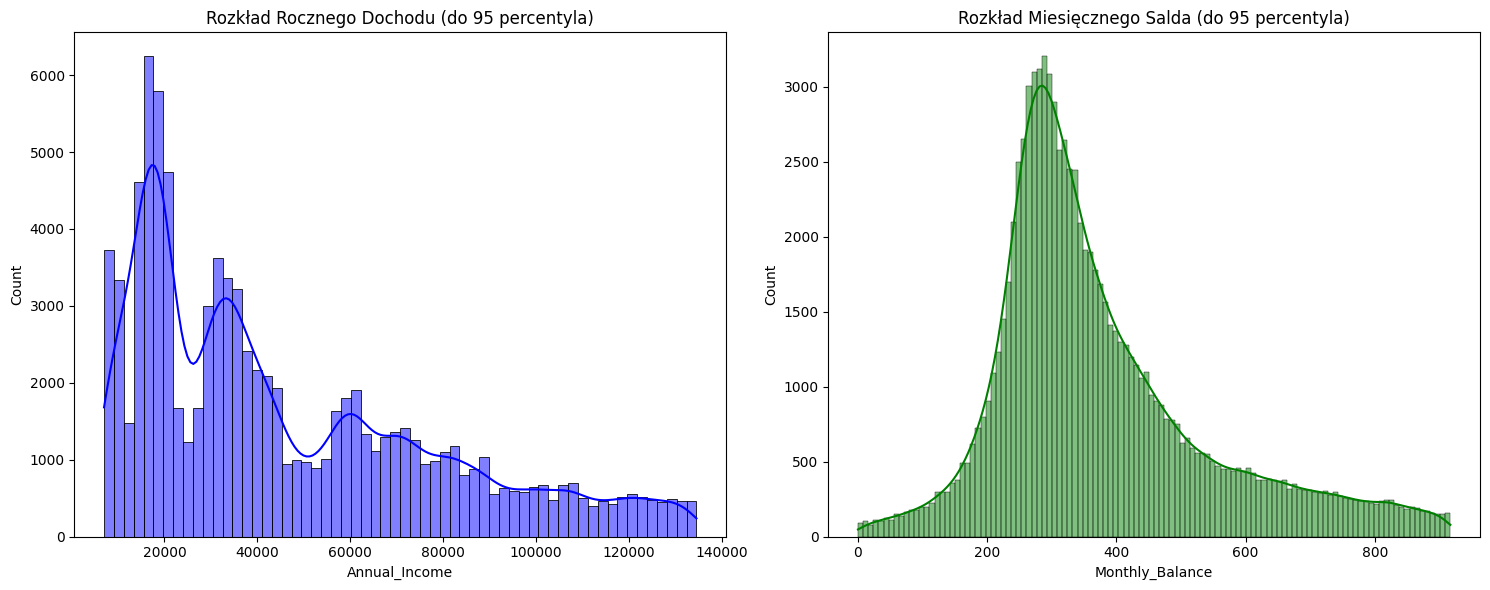

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Upewniamy się, że dane są liczbami i usuwamy wartości ekstremalne (tylko do wykresu)
temp_df = df.copy()
temp_df['Monthly_Balance'] = pd.to_numeric(temp_df['Monthly_Balance'], errors='coerce')
temp_df['Annual_Income'] = pd.to_numeric(temp_df['Annual_Income'], errors='coerce')

# 2. Usuwamy NaN, żeby nie psuły wykresu
temp_df = temp_df.dropna(subset=['Monthly_Balance', 'Annual_Income'])

# 3. Filtrujemy dane do rozsądnych granic (np. 95 percentyl), żeby uniknąć błędu "size exceeded"
# To pozwoli zobaczyć główną część danych bez błędnych rekordów-gigantów
income_limit = temp_df['Annual_Income'].quantile(0.95)
balance_limit = temp_df['Monthly_Balance'].quantile(0.95)

plt.figure(figsize=(15, 6))

# Rozkład Annual_Income
plt.subplot(1, 2, 1)
sns.histplot(temp_df[temp_df['Annual_Income'] <= income_limit]['Annual_Income'], kde=True, color='blue')
plt.title('Rozkład Rocznego Dochodu (do 95 percentyla)')

# Rozkład Monthly_Balance
plt.subplot(1, 2, 2)
sns.histplot(temp_df[temp_df['Monthly_Balance'] <= balance_limit]['Monthly_Balance'], kde=True, color='green')
plt.title('Rozkład Miesięcznego Salda (do 95 percentyla)')

plt.tight_layout()
plt.show()

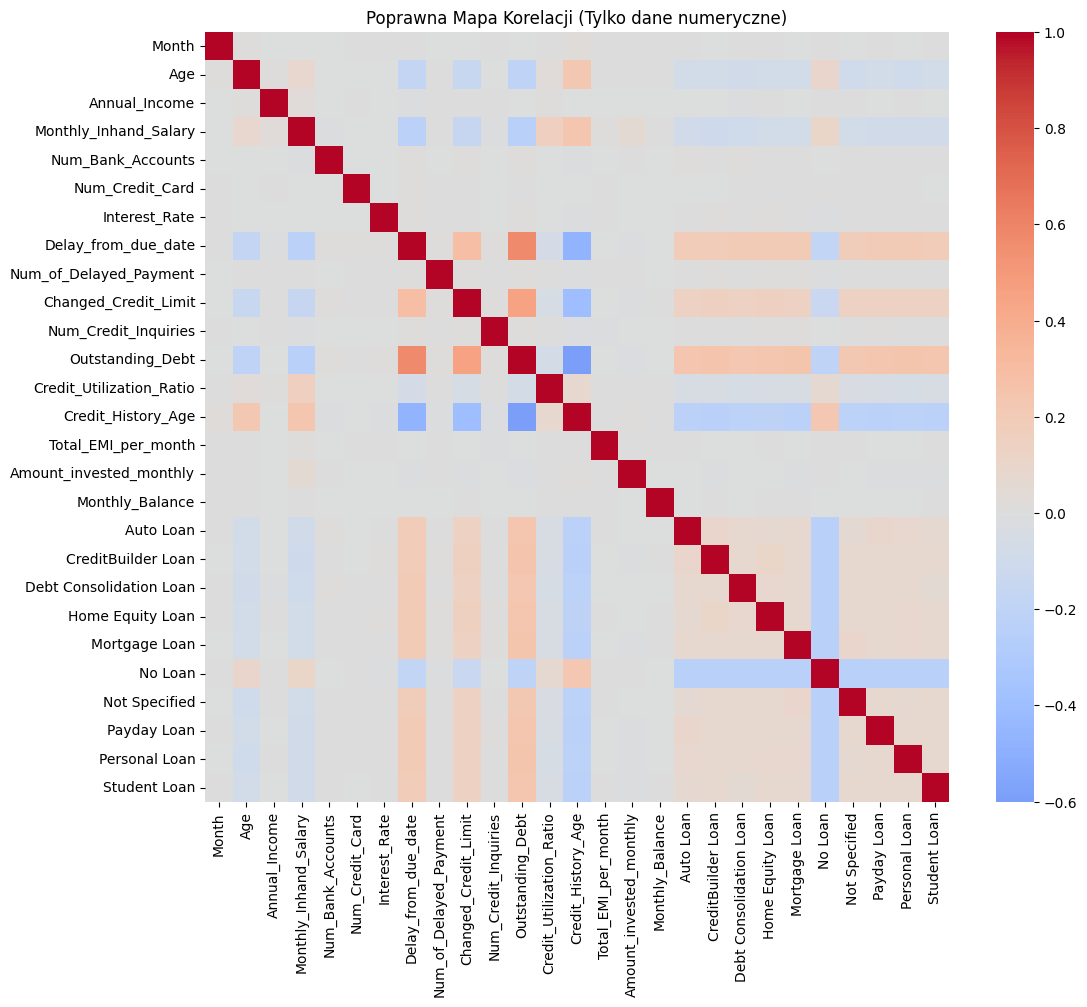

✅ Kolumna Credit_History_Age została przeliczona na miesiące.
✅ Mapa korelacji została wygenerowana poprawnie.


In [18]:
import re

# Funkcja wyciągająca liczby z tekstu "X Years and Y Months"
def extract_months(text):
    if pd.isna(text) or str(text).strip() == "":
        return np.nan
    try:
        # Znajduje wszystkie liczby w tekście
        numbers = re.findall(r'\d+', str(text))
        if len(numbers) == 2:
            return int(numbers[0]) * 12 + int(numbers[1])
        elif len(numbers) == 1:
            return int(numbers[0])
        return np.nan
    except:
        return np.nan

# Aplikujemy funkcję
df['Credit_History_Age'] = df['Credit_History_Age'].apply(extract_months)

# Uzupełniamy ewentualne braki w tej nowej kolumnie średnią (żeby korelacja działała)
df['Credit_History_Age'] = df['Credit_History_Age'].fillna(df['Credit_History_Age'].mean())

# Teraz wybieramy tylko kolumny, które SĄ numeryczne (to zapobiegnie kolejnym błędom float)
numeric_df = df.select_dtypes(include=[np.number])

# Rysujemy mapę korelacji
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Poprawna Mapa Korelacji (Tylko dane numeryczne)')
plt.show()

print("✅ Kolumna Credit_History_Age została przeliczona na miesiące.")
print("✅ Mapa korelacji została wygenerowana poprawnie.")

In [19]:
from sklearn.preprocessing import LabelEncoder

# 1. Kodujemy Credit_Mix (Ważne: zachowujemy kolejność logiczną)
# Bad < Standard < Good
mix_mapping = {'Bad': 0, 'Standard': 1, 'Good': 2}
if 'Credit_Mix' in df.columns:
    df['Credit_Mix'] = df['Credit_Mix'].map(mix_mapping).fillna(1) # uzupełniamy braki 'Standardem'

# 2. Kodujemy Payment_of_Min_Amount (Yes/No)
min_pay_mapping = {'No': 0, 'Yes': 1, 'NM': 0} # NM traktujemy jako No/brak danych
if 'Payment_of_Min_Amount' in df.columns:
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map(min_pay_mapping).fillna(0)

# 3. Kodujemy Occupation i Credit_Score za pomocą LabelEncodera
le = LabelEncoder()
for col in ['Occupation', 'Credit_Score']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# 4. Upewniamy się, że Num_of_Loan jest liczbą
if 'Num_of_Loan' in df.columns:
    df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'], errors='coerce').fillna(0)

print("✅ Dodano i zakodowano brakujące kolumny: Occupation, Credit_Mix, Payment_of_Min_Amount, Credit_Score.")
print(f"Obecna liczba kolumn: {df.shape[1]}")

✅ Dodano i zakodowano brakujące kolumny: Occupation, Credit_Mix, Payment_of_Min_Amount, Credit_Score.
Obecna liczba kolumn: 33
